In [1]:
import numpy as np
import matplotlib.pyplot as plt


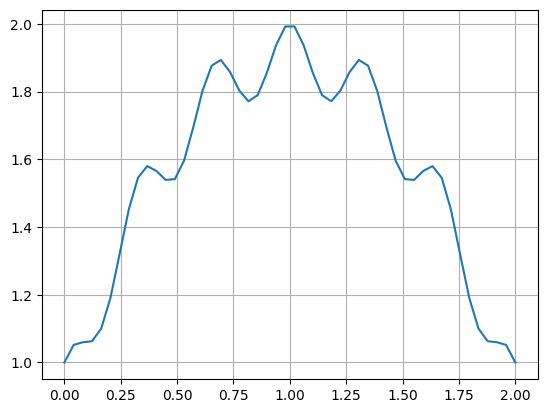

In [2]:
x = np.linspace(0,2,50)
y = -(0.1+(1-x)**2-0.1*np.cos(6*np.pi*(1-x)))+2
plt.plot(x,y)
plt.grid()
plt.show()

In [3]:
#FUNCION PARA CREAR UNA POBLACION DE INDIVIDUOS EN REPRESENTACION BINARIA

def iniPob(n,l): #n: numero de individuos (tamañao de poblacion), l:longitud de os cromosomas
  poblacion = np.random.randint(0,2,size=(n,l))
  return poblacion



In [4]:
# FUNCION PARA DECODIFICAR DE BINARIO A DECIMAL LOS INDIVIDUOS
def decodificar(poblacion, Imin, Imax):
  [r,c] = poblacion.shape
  decimal = np.zeros(r)
  decimal_reescalado = np.zeros(r)

  for i in range(r):
    for j in range(c):
      #Se tranforma la cadena binaria a entero
      decimal[i] = decimal[i]+ poblacion[i,j]*2**(c-j-1)
      #se reescala el valor decimal en el espacio de la busqueda
      decimal_reescalado[i] = (Imax-Imin)*decimal[i]/(2**c-1)+Imin

  return decimal_reescalado

P = iniPob(10,8)
x = decodificar(P,0,2)

print(x)

[1.92941176 1.05882353 1.70980392 1.11372549 0.25882353 1.46666667
 1.45882353 0.00784314 1.63137255 1.98431373]


In [5]:
#FUNCION PAEA OBTENER LAS APTITUDES (Fitness) DE LOS INDIVIDUOS

def fitness(poblacion,Imin,Imax):
  [r,c] = poblacion.shape
  x = decodificar(poblacion,Imin,Imax)
  fitness = -(0.1+(1-x)**2-0.1*np.cos(6*np.pi*(1-x)))+2 #funcion objetivo
  return fitness

P = iniPob(10,8)
aptitud = fitness(P,0,2)
print(aptitud)

[1.89296529 1.1899193  1.21269267 1.21269267 1.56042536 1.53941428
 1.02678693 1.82258761 1.89296529 1.77151007]


In [6]:
#Función que realiza la cruza de los individuos
def cruza(Poblacion,pc):
    [r,c] = Poblacion.shape
    #pc: pares de cromozomas a cruzar
    M = np.zeros((2*pc,c))#Matriz que almacena los nuevos individuos
    for i in range (pc):
        r1 = np.random.randint(0,r,size=(1,2)) #selecciona un individuo al azar
        #Número aleatorio para elegir el punto de cruza
        r2 = np.random.randint(0,c)
        
        #Seleccionamos a los padres a cruzar 
        Padre1= Poblacion[r1[0,0],:]
        Padre2= Poblacion[r1[0,1],:]

        #Se Crean los descendientes
        Hijo1 = np.concatenate((Padre1[0:r2],Padre2[r2:]))
        Hijo2 = np.concatenate((Padre2[0:r2],Padre1[r2:]))

        #Se van almacenando los nuevos individuos en la matriz M
        M[2*i,:] = Hijo1
        M[2*i+1,:] = Hijo2
    return M

#Probamos la función de cruza
P = iniPob(10,8)
print("Poblacion inicial")
print(P)
H = cruza(P,5)
print("Descendencia")   
print(H)

Poblacion inicial
[[0 0 1 1 1 1 0 0]
 [1 0 1 0 1 0 0 1]
 [0 1 1 0 1 0 0 1]
 [0 1 0 0 0 1 0 0]
 [0 0 1 1 0 1 1 1]
 [1 1 0 1 1 1 1 1]
 [1 0 0 0 0 0 0 1]
 [1 1 1 1 0 1 0 1]
 [1 0 1 0 0 1 0 0]
 [0 1 1 0 1 1 1 1]]
Descendencia
[[1. 0. 1. 0. 1. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 1. 0. 0.]
 [1. 1. 1. 0. 1. 1. 1. 1.]
 [0. 1. 1. 0. 1. 0. 0. 1.]
 [1. 1. 1. 1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 1. 1. 1. 1.]
 [1. 1. 0. 0. 0. 1. 0. 0.]
 [0. 1. 1. 0. 1. 1. 1. 0.]
 [0. 1. 0. 0. 0. 1. 0. 1.]]


In [7]:
#Función que realiza la mutación de los individuos
def mutacion(Poblacion,pm):
    [r,c] = Poblacion.shape
    n=int(pm*c)
    r1 = np.random.randint(0,r) #selecciona un individuo al azar
    r2 = np.random.randint(0,c) #selecciona un gen al azar
    if Poblacion[r1,r2]==0:
        Poblacion[r1,r2]=1
    else:
        Poblacion[r1,r2]=0
        return Poblacion

In [8]:
#Funcion que realiza el proceso de seleccion por ranking
def seleccion_ranking(Poblacion,ps):
    [r,c]=Poblacion.shape
    Pnew=np.zeros((r,c))
    n=int(ps*r) #numero de individuos a seleccionar
    aptitud = fitness(Poblacion).reshape(r,1)
    Pob_ampliada = np.concatenate((Poblacion,aptitud),axis=1)
    Indices = np.argsort(Pob_ampliada[:,-1])[::-1]
    Pob_ordenada = Pob_ampliada[Indices]
    Pob_ordenada_seleccionada = Pob_ordenada[0:n,:]
    Pob_ordenada_seleccionada_final = Pob_ordenada_seleccionada[:,0:c]
    for i in range(r):
        for j in range(c):
            if (i<n):
                Pnew[i,j] = Pob_ordenada_seleccionada_final[i,j]
            else:
                Pnew[i,j] = np.random.randint(0,2)
    return Pnew


In [9]:
#Función que realiza la selección por torneo
def seleccion_torneo(Poblacion,Imin,Imax,k):
    #k: tamaño del torneo
    [r,c]=Poblacion.shape
    aptitud = fitness(Poblacion).reshape(r,1)
    M = np.concatenate((Poblacion,aptitud),axis=1)

   #Seleccionamos k individuos al azar paraa el torneo
    indices_torneo = np.random.choice(r,size=k,replace=False)
    torneo = M[indices_torneo,:]

    #Ordenamos por aptitud a los individuos del torneo de manera descendente
    indices = np.argsort(torneo[:,-1])[::-1]
    torneo_ordenado = torneo[indices]

    #Mantenemos al mejor individuo 
    mejor_individuo = torneo_ordenado[0,0:c]

    return mejor_individuo

In [ ]:
#Función que crea una nueva poblacion mediante el torneo 
def nueva_poblacion_torneo(Poblacion,Imin,Imax,k):
    [r,c]=Poblacion.shape
    Pnew = np.zeros((r,c))
    #se repite el torneo para llenar la matriz de la nueva poblacion
    for i in range(r):
        Pnew[i,:] = seleccion_torneo(Poblacion,Imin,Imax,k)
    return Pnew
    

In [ ]:
#Función que realiza selección por ruleta
def seleccion_ruleta(Poblacion,Imin,Imax):
    [r,c] = Poblacion.shape
    aptitud = fitness(Poblacion,Imin,Imax)
    min_f = np.min(aptitud)
    if min_f < 0:
        aptitud = aptitud - min_f + 1e-6  # Ajuste para evitar valores negativos
    #Evitemos la división por cero
    if np.sum(aptitud) == 0:
        probs = np.ones(r)/r
    else: 
        probs = aptitud/np.sum(aptitud)

    #Obtenemos las probabilidades acumuladas
    acumuladas = np.cumsum(probs)

    #Generamos un número aleatorio para simular la rotación de la ruleta
    num = np.random.rand()

    #Se busca el individuo donde cae num
    for i in range(r):
        if num<acumuladas[i]:
            ganador = Poblacion[i,:]
            break
    return ganador

    #Función que crea una nueva poblacion mediante ruleta 
def nueva_poblacion_ruleta(Poblacion,Imin,Imax):
    [r,c]=Poblacion.shape
    Pnew = np.zeros((r,c))

    #se repite la ruleta para llenar la matriz de la nueva poblacion
    for i in range(r):
        Pnew[i,:] = seleccion_ruleta(Poblacion,Imin,Imax)
    return Pnew


In [20]:
import numpy as np
#implementamos el algoritmo genético completo
print("Algoritmo Genético (Representación Binaria)\n")
#*************Parametros de arranque*****************
n=100 #numero de individuos
L=8 #longitud de los cromosomas
generaciones= 200 #numero de generaciones
ps = 0.6 #porcentaje de seleccion
pc = n/2 #Par de cromosomas a cruzar
pm = 0.05 #probabilidad de mutacion
Imin = 0
Imax = 2
#****************************************************
#reescribimos las funciones para que trabajen con los parametros de arranque

def iniPob(n,l): #n: numero de individuos (tamañao de poblacion), l:longitud de los cromosomas
  poblacion = np.random.randint(0,2,size=(n,l))
  return poblacion

# FUNCION PARA DECODIFICAR DE BINARIO A DECIMAL LOS INDIVIDUOS
def decodificar(poblacion, Imin, Imax):
  [r,c] = poblacion.shape
  decimal = np.zeros(r)
  decimal_reescalado = np.zeros(r)

  for i in range(r):
    for j in range(c):
      #Se tranforma la cadena binaria a entero
      decimal[i] = decimal[i]+ poblacion[i,j]*2**(c-j-1)
      #se reescala el valor decimal en el espacio de la busqueda
      decimal_reescalado[i] = (Imax-Imin)*decimal[i]/(2**c-1)+Imin

  return decimal_reescalado

#FUNCION PAEA OBTENER LAS APTITUDES (Fitness) DE LOS INDIVIDUOS

def fitness(poblacion,Imin,Imax):
  [r,c] = poblacion.shape
  x = decodificar(poblacion,Imin,Imax)
  fitness = -(0.1+(1-x)**2-0.1*np.cos(6*np.pi*(1-x)))+2 #funcion objetivo
  return fitness

#Función que realiza la cruza de los individuos
def cruza(Poblacion,pc):
    [r,c] = Poblacion.shape
    #pc: pares de cromozomas a cruzar
    M = np.zeros((2*pc,c))#Matriz que almacena los nuevos individuos
    for i in range (pc):
        r1 = np.random.randint(0,r,size=(1,2)) #selecciona un individuo al azar
        #Número aleatorio para elegir el punto de cruza
        r2 = np.random.randint(0,c)
        
        #Seleccionamos a los padres a cruzar 
        Padre1= Poblacion[r1[0,0],:]
        Padre2= Poblacion[r1[0,1],:]

        #Se Crean los descendientes
        Hijo1 = np.concatenate((Padre1[0:r2],Padre2[r2:]))
        Hijo2 = np.concatenate((Padre2[0:r2],Padre1[r2:]))

        #Se van almacenando los nuevos individuos en la matriz M
        M[2*i,:] = Hijo1
        M[2*i+1,:] = Hijo2
    return M

#Función que realiza la mutación de los individuos
def mutacion(Poblacion,pm):
    [r,c] = Poblacion.shape
    n=int(pm*c)
    r1 = np.random.randint(0,r) #selecciona un individuo al azar
    r2 = np.random.randint(0,c) #selecciona un gen al azar
    if Poblacion[r1,r2]==0:
        Poblacion[r1,r2]=1
    else:
        Poblacion[r1,r2]=0
    return Poblacion
    
    #Funcion que realiza el proceso de seleccion por ranking
def seleccion_ranking(Poblacion,ps):
    [r,c]=Poblacion.shape
    Pnew=np.zeros((r,c))
    n=int(ps*r) #numero de individuos a seleccionar
    aptitud = fitness(Poblacion,Imin,Imax).reshape(r,1)
    Pob_ampliada = np.concatenate((Poblacion,aptitud),axis=1)
    Indices = np.argsort(Pob_ampliada[:,-1])[::-1]
    Pob_ordenada = Pob_ampliada[Indices]
    Pob_ordenada_seleccionada = Pob_ordenada[0:n,:]
    Pob_ordenada_seleccionada_final = Pob_ordenada_seleccionada[:,0:c]
    for i in range(r):
        for j in range(c):
            if (i<n):
                Pnew[i,j] = Pob_ordenada_seleccionada_final[i,j]
            else:
                Pnew[i,j] = np.random.randint(0,2)
    return Pnew

#Función que realiza la selección por torneo
def seleccion_torneo(Poblacion,Imin,Imax,k):
    #k: tamaño del torneo
    [r,c]=Poblacion.shape
    aptitud = fitness(Poblacion,Imin,Imax).reshape(r,1)
    M = np.concatenate((Poblacion,aptitud),axis=1)

   #Seleccionamos k individuos al azar paraa el torneo
    indices_torneo = np.random.choice(r,size=k,replace=False)
    torneo = M[indices_torneo,:]

    #Ordenamos por aptitud a los individuos del torneo de manera descendente
    indices = np.argsort(torneo[:,-1])[::-1]
    torneo_ordenado = torneo[indices]

    #Mantenemos al mejor individuo 
    mejor_individuo = torneo_ordenado[0,0:c]

    return mejor_individuo

#Función que crea una nueva poblacion mediante el torneo 
def nueva_poblacion_torneo(Poblacion,Imin,Imax,k):
    [r,c]=Poblacion.shape
    Pnew = np.zeros((r,c))
    #se repite el torneo para llenar la matriz de la nueva poblacion
    for i in range(r):
        Pnew[i,:] = seleccion_torneo(Poblacion,Imin,Imax,k)
    return Pnew

#Función que realiza selección por ruleta
def seleccion_ruleta(Poblacion,Imin,Imax):
    [r,c] = Poblacion.shape
    aptitud = fitness(Poblacion,Imin,Imax)
    min_f = np.min(aptitud)
    if min_f < 0:
        aptitud = aptitud - min_f + 1e-6  # Ajuste para evitar valores negativos
    #Evitemos la división por cero
    if np.sum(aptitud) == 0:
        probs = np.ones(r)/r
    else: 
        probs = aptitud/np.sum(aptitud)

    #Obtenemos las probabilidades acumuladas
    acumuladas = np.cumsum(probs)

    #Generamos un número aleatorio para simular la rotación de la ruleta
    num = np.random.rand()

    #Se busca el individuo donde cae num
    for i in range(r):
        if num<acumuladas[i]:
            ganador = Poblacion[i,:]
            break
    return ganador

    #Función que crea una nueva poblacion mediante ruleta 
def nueva_poblacion_ruleta(Poblacion,Imin,Imax):
    [r,c]=Poblacion.shape
    Pnew = np.zeros((r,c))

    #se repite la ruleta para llenar la matriz de la nueva poblacion
    for i in range(r):
        Pnew[i,:] = seleccion_ruleta(Poblacion,Imin,Imax)
    return Pnew

#Implementacion del algoritmo genetico
P = iniPob(n,L) # Se crea poblacion aleatoria
for i in range(generaciones):
   C = cruza(P, int(pc))
   M = mutacion(C,pm)
   #Pnew = seleccion_ranking(M,ps)
   #Pnew = nueva_poblacion_torneo(M,Imin,Imax,3)
   Pnew = nueva_poblacion_ruleta(M,Imin,Imax)

   P = Pnew.copy()

#*****************RESULTADOS*****************
p_mejor_decimal = decodificar(P,Imin,Imax) #
x_mejor = p_mejor_decimal[0] #Mejor individuo
print(f'El mejor individuo es: {Pnew[0,:]}')
print(f'El valor que representa es: {x_mejor}')
print(f' el valor fitness del mejor individuo es: {fitness(Pnew,Imin,Imax)[0]}')


Algoritmo Genético (Representación Binaria)

El mejor individuo es: [0. 1. 1. 1. 1. 1. 1. 1.]
El valor que representa es: 0.996078431372549
 el valor fitness del mejor individuo es: 1.999711538638079



## ALGORITMO GENÉTICO: REPRESENTACIÓN REAL

In [ ]:
#Algoritmo Genético (Representación Real)
n = 100
l = 1
generaciones = 100
ps = 0.6 #porcentaje de seleccion
pc = 0.5 #Par de cromosomas a cruzar
pm = 0.05 #probabilidad de mutacion
Imin = -2
Imax = 2

#---------------------------------Funciones---------------------------------
#Funcion para crear vector de individuos 
def iniPob(n,l,Imin,Imax): #n: numero de individuos (tamañao de poblacion), l:longitud de los cromosomas
  poblacion = np.random.uniform(Imin,Imax,size=(n,l))
  return poblacion

def fitness(Poblacion): #función para obtener las aptitudes (Fitness) de los individuos
    fitness = -(0.1+(1-Poblacion)**2-0.1*np.cos(6*np.pi*(1-Poblacion)))+2 #funcion objetivo
    return fitness

def cruza(Poblacion,pc,Imin,Imax): #Función que realiza la cruza de los individuos
    [r,c] = Poblacion.shape
    n = int(r*pc)
    M = np.zeros((r,1))

    for i in range(n):
        r1 = np.random.randint(0,r,size=(1,2))
        Padre1 = Poblacion[r1[0,0],0]
        Padre2 = Poblacion[r1[0,1],0]
        alpha = np.random.rand()
        Hijo1 = alpha*Padre1 + (1-alpha)*Padre2
        Hijo2 = (1-alpha)*Padre1 + alpha*Padre2

        #Mantenenemos a los hijos en el rango [Imin,Imax]
        Hijo1 = np.clip(Hijo1,Imin,Imax)
        Hijo2 = np.clip(Hijo2,Imin,Imax)
        #Se van almacenando los nuevos individuos en la matriz M
        M[2*i,0] = Hijo1
        M[2*i+1,0] = Hijo2
    for i in range(r):
        if M[i,0] == 0: 
            M[i,0] = np.random.uniform(Imin,Imax)
    return M

def mutacion(Poblacion,pm,Imin,Imax,beta =.05): #Función que realiza la mutación de los individuos
    [r,c] = Poblacion.shape
    sigma = beta*(Imax-Imin)
    n=int(np.ceil(pm*r))

    for i in range(n):
        r1 = np.random.randint(0,r) #selecciona un individuo al azar
        N = np.random.normal(0,sigma) #numero aleatorio con distribución normal
        Poblacion[r1,0] = Poblacion[r1,0] + N
    return Poblacion
        
def seleccion_ranking(Poblacion,ps,Imin,Imax): #Funcion que realiza el proceso de seleccion por ranking
    [r,c]=Poblacion.shape
    Pnew=np.zeros((r,1))
    n=int(ps*r) #numero de individuos a seleccionar
    aptitud = fitness(Poblacion).reshape(r,1)
    Pob_ampliada = np.concatenate((Poblacion,aptitud),axis=1)
    Indices = np.argsort(Pob_ampliada[:,-1])[::-1]
    Pob_ordenada = Pob_ampliada[Indices]
    Pob_ordenada_seleccionada = Pob_ordenada[0:n,:]
    Pob_ordenada_seleccionada_final = Pob_ordenada_seleccionada[:,0]
    for i in range(r):
            if (i<n):
                Pnew[i] = Pob_ordenada_seleccionada_final[i]
            else:
                Pnew[i] = np.random.uniform(Imin,Imax)
    return Pnew

#-----------------------ALGORITMO GENÉTICO ---------------------
P = iniPob(n,l,Imin,Imax) # Se crea poblacion aleatoria

for k in range(generaciones):
    C = cruza(P,pc,Imin,Imax)
    M = mutacion(C,pm,Imin,Imax)
    Pnew = seleccion_ranking(M,ps,Imin,Imax)

#Resultados
x_mejor = Pnew[0,0] #Mejor individuo
print(f'El mejor individuo es: {Pnew[0,:]}')
print(f'El valor que representa es: {x_mejor}')
print(f' el valor fitness del mejor individuo es: {fitness(Pnew)[0]}')

(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(100, 1)
(